# Part 1: Data Analysis

The goal of this notebook is to practice the techniques introduced in **Part 1: Data Analysis** of *Advances in Financial Machine Learning* by Marcos López de Prado. Through Python implementations and experiments with financial data, I aim to understand how these methods prepare data for financial machine learning.

The notebook is organized into four sections:

1. **Financial Data Structures** — Explore how financial observations are organized, sampled, and transformed into useful datasets.
2. **Labeling** — Practice assigning targets to financial observations, including the triple-barrier method and meta-labeling.
3. **Sample Weights** — Explore how overlapping observations, sample uniqueness, and time decay affect the weight assigned to each training example.
4. **Fractionally Differentiated Features** — Practice fractional differentiation to balance stationarity with the preservation of information from past observations.

Each section will combine explanations, code, and observations from the results to build a practical understanding of the techniques.


## Study Signal: Wilder's 14-Period RSI

We will use **Wilder's 14-period Relative Strength Index (RSI)** to define entry signals, first for **MSFT**, then for each stock in the small-, medium-, and large-cap baskets. A period is one price bar: 14 hourly bars with `interval="1H"` or 14 daily bars with `interval="1D"`.

### RSI calculation

For closing price $P_t$, define the price change, gain, and nonnegative loss:

$$
\Delta P_t=P_t-P_{t-1},\qquad
G_t=\max(\Delta P_t,0),\qquad
L_t=\max(-\Delta P_t,0).
$$

Initialize the averages with the first 14 price changes (requiring 15 closing prices):

$$
\overline{G}_{14}=\frac{1}{14}\sum_{i=1}^{14}G_i,
\qquad
\overline{L}_{14}=\frac{1}{14}\sum_{i=1}^{14}L_i.
$$

For subsequent bars, apply Wilder's recursive smoothing:

$$
\overline{G}_t=\frac{13\overline{G}_{t-1}+G_t}{14},
\qquad
\overline{L}_t=\frac{13\overline{L}_{t-1}+L_t}{14}.
$$

Relative strength and RSI are then:

$$
RS_t=\frac{\overline{G}_t}{\overline{L}_t},
\qquad
RSI_t=100-\frac{100}{1+RS_t}.
$$

If average loss is zero and average gain is positive, RSI is 100; if average gain is zero and average loss is positive, RSI is 0. For this study, we will assign RSI = 50 when both averages are zero. RSI remains unavailable until the initial 14 price changes exist.

### Entry rules

We interpret crossing oversold as entering below 30, and crossing overbought as entering above 70:

$$
s_t=
\begin{cases}
+1 & \text{if } RSI_{t-1}\geq30\text{ and }RSI_t<30\quad\text{(long entry)},\\
-1 & \text{if } RSI_{t-1}\leq70\text{ and }RSI_t>70\quad\text{(short entry)},\\
0 & \text{otherwise (no new entry)}.
\end{cases}
$$

The signal is an entry event rather than a continuously held position. Staying beyond a threshold does not generate another entry. Evaluate crossings only when both RSI values are available, and act after bar $t$ closes. Holding periods and exits will be specified in the labeling study.

**Reference:** [RSI calculation and Wilder smoothing — StockCharts ChartSchool](https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi).


Loaded 3,467 hourly bars
Available range: 2024-10-04 13:30:00-04:00 to 2026-10-02 15:30:00-04:00


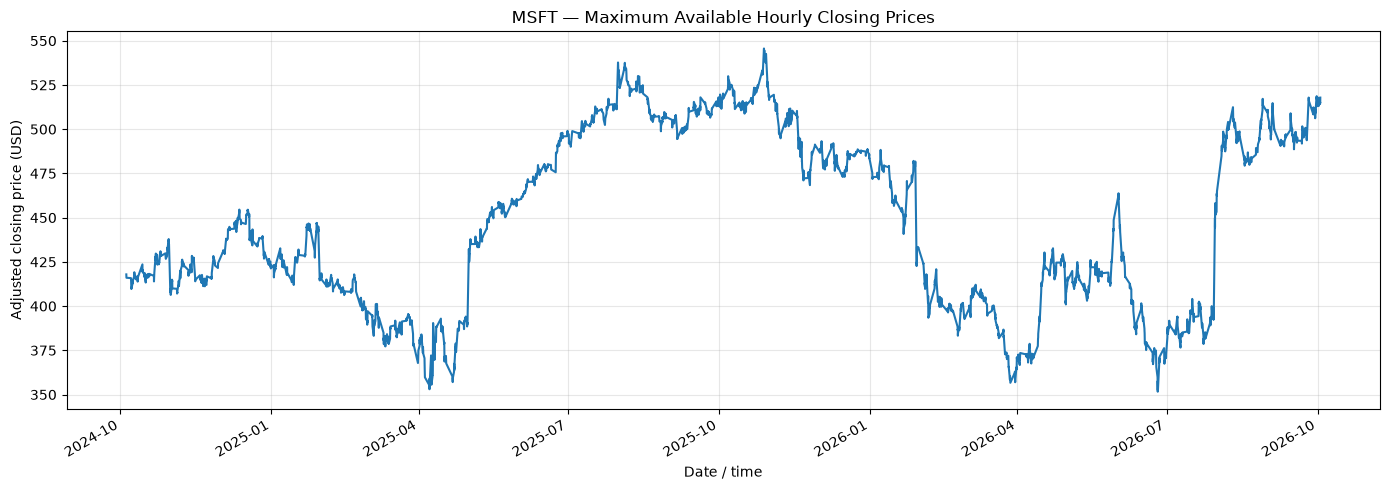

In [11]:
import matplotlib.pyplot as plt
import yfinance as yf

# Request the maximum hourly history Yahoo Finance makes available.
# Hourly history is limited to roughly the most recent 730 days.
msft_hourly = yf.Ticker("MSFT").history(
    period="max",
    interval="1h",
    auto_adjust=True,
)
if msft_hourly.empty:
    raise ValueError("Yahoo Finance returned no hourly MSFT data.")

msft_hourly = msft_hourly.sort_index()
msft_prices = msft_hourly[["Close"]].rename(columns={"Close": "MSFT"})
print(f"Loaded {len(msft_prices):,} hourly bars")
print(f"Available range: {msft_prices.index.min()} to {msft_prices.index.max()}")

ax = msft_prices.plot(
    figsize=(14, 5),
    legend=False,
    title="MSFT — Maximum Available Hourly Closing Prices",
)
ax.set_xlabel("Date / time")
ax.set_ylabel("Adjusted closing price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


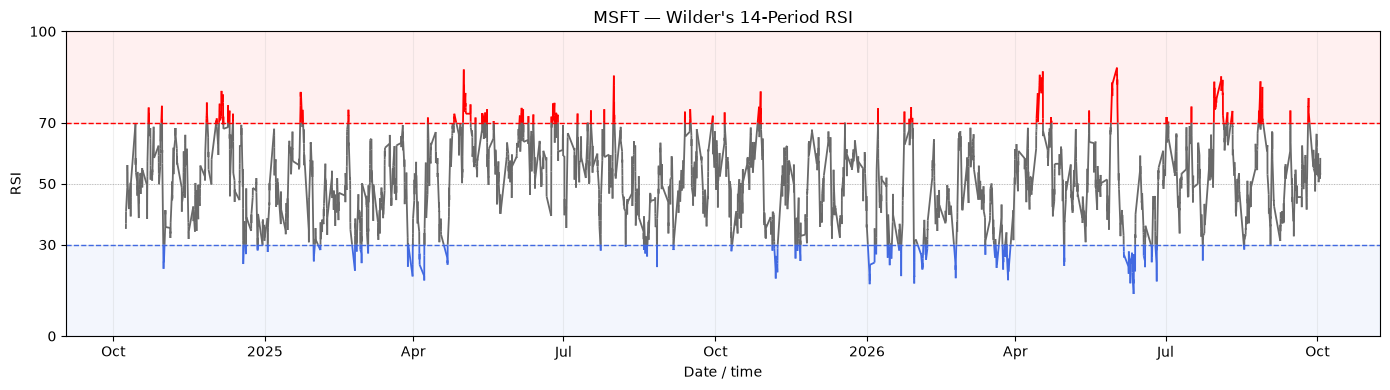

Total signals: 140
Sell signals (short entries): 75
Buy signals (long entries): 65


In [12]:
from pathlib import Path
import sys

# Add the project root before importing the HelperFunctions package.
project_root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "HelperFunctions" / "signals.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Cannot locate HelperFunctions/signals.py. Start the notebook kernel "
        "from the QuantitativeMethods project folder or one of its subfolders."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from HelperFunctions.signals import wilder_rsi

# Accepts one or many ticker columns; plotting is optional.
msft_rsi = wilder_rsi(msft_prices, periods=14, plot=True)

# Count threshold crossings only, rather than every bar beyond a threshold.
previous_rsi = msft_rsi.shift(1)
valid_rsi = msft_rsi.notna() & previous_rsi.notna()
buy_signals = valid_rsi & (previous_rsi >= 30) & (msft_rsi < 30)
sell_signals = valid_rsi & (previous_rsi <= 70) & (msft_rsi > 70)

buy_count = int(buy_signals.to_numpy().sum())
sell_count = int(sell_signals.to_numpy().sum())
total_signals = buy_count + sell_count
print(f"Total signals: {total_signals:,}")
print(f"Sell signals (short entries): {sell_count:,}")
print(f"Buy signals (long entries): {buy_count:,}")
